## KNN Algorithm (K-Nearest Neighbor)
- Supervised machine learning algorithm (since it has both input and output provided to train)
- It can be used for both regression and classification
- This is applied for cases where its hard to draw a classification line
- How KNN works for classification problem?
    - It works for nonlinear data where one cannot apply logistic regression
    - Step1: Define number of nearest neighbors (say k=5)
    - Step2: Take a testing observation and calculate distance from training observation set and select top 5 smallest distances and count those five points as nearest neighbors
    - Step3: Calculate the probability of both the classes of these five points. Based on the class of majority of points, we assign the testing point with that class
        -  We always choose odd value for k, so that it doesn't tie. If we use even k, we can do regression(for regression both even or odd value of k works), and not classification. k = 1,2,3 might give large error as it might hinder the consideration of majority of surrounding points
- How KNN works for regression problems?
    - It works for nonlinear data
    -Step1:Define number of nearest neighbors, k.
    -Step2: Take a testing observation and find five nearest numbers
    -Step3: Take average of all 5 NN and assign the value to the testing point
- The k value needs to be decided in advance
- KNN is called as **lazy learner algorithm** (while all other algorithms are called eager learners) because, there is no training phase. It starts learning and working only once test data comes, unlike other algorithms where in a model is developed with training data and tested on test data. 
- The training time is very less, it just reads the data in the phase, and does nothing else in regards to the model
- It requires more space as compared to other algorithms as both training and testing data needs to be stored parallely
- 

In [2]:
# Business Case:-To predict whether a person will have diabetes or not.

In [11]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
# Reading the data
data = pd.read_csv("diabetes.csv")
pd.set_option('display.max_rows',None)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
5,0,173,78,32,265,46.5,1.159,58,0
6,4,99,72,17,0,25.6,0.294,28,0
7,8,194,80,0,0,26.1,0.551,67,0
8,2,83,65,28,66,36.8,0.629,24,0
9,2,89,90,30,0,33.5,0.292,42,0


## Basic Checks

## EDA

## Data Preprocessing

In [15]:
data.isnull().sum() 

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
data.loc[data.Glucose==0,'Glucose'] = np.median(data.Glucose)
data.loc[data.BloodPressure==0,'BloodPressure'] = np.median(data.BloodPressure)
data.loc[data.SkinThickness==0,'SkinThickness'] = np.median(data.SkinThickness)
data.loc[data.Insulin==0,'Insulin'] = np.median(data.Insulin)
data.loc[data.BMI==0,'BMI'] = np.median(data.BMI)

## Task: Handling with outliers, and perform feature selection

## Model Creation

In [22]:
x = data.drop('Outcome',axis = 1)
y = data.Outcome

### Scaling

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_scaled,columns = x.columns)

In [39]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.058824,0.303226,0.306122,0.166667,0.117808,0.112179,0.066610,0.033333
1,0.058824,0.774194,0.591837,0.343137,0.072603,0.233974,0.112297,0.483333
2,0.000000,0.193548,0.285714,0.019608,0.030137,0.153846,0.081554,0.016667
3,0.352941,0.580645,0.571429,0.284314,0.487671,0.448718,0.068318,0.416667
4,0.176471,0.296774,0.551020,0.147059,0.035616,0.392628,0.205380,0.000000
5,0.235294,0.341935,0.367347,0.147059,0.035616,0.160256,0.155850,0.016667
6,0.000000,0.374194,0.408163,0.372549,0.087671,0.358974,0.178480,0.000000
7,0.058824,0.470968,0.510204,0.117647,0.012329,0.152244,0.094364,0.000000
8,0.235294,0.354839,0.530612,0.068627,0.050685,0.080128,0.061913,0.000000
9,0.117647,0.548387,0.489796,0.147059,0.035616,0.325321,0.096499,0.333333


In [29]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors = 5)
KNN.fit(x_train,y_train)
x_test_scaled = scaler.transform(x_test)
x_test = pd.DataFrame(x_test_scaled,columns = x.columns)
y_pred = KNN.predict(x_test)
(y_test != y_pred).sum()
(y_test != y_pred).sum()*100/500   #19.6% error

19.4

## Error Calculation and finding right k:
- No name for error specifically
- Calculate the value of error for different values of k. The value of k for which the error is least, is picked as right k

In [32]:
import warnings
warnings.filterwarnings('ignore')
xtr = x_train
ytr = y_train
yte = y_test
xte = x_test
err = []
for i in range(1,11):
    KNN = KNeighborsClassifier(n_neighbors = i)
    KNN.fit(xtr,ytr)
    ypr = KNN.predict(xte)
    err.append((yte != ypr).sum()*100/len(yte))
err


[3.6, 13.8, 19.2, 20.4, 19.4, 19.6, 20.0, 20.2, 20.8, 21.0]

Text(0.5, 1.0, 'K vs Error')

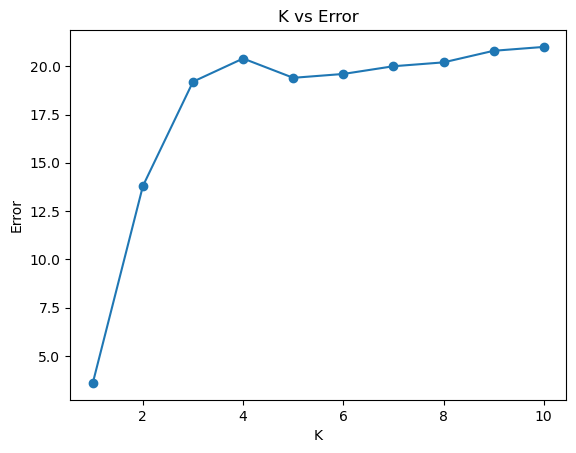

In [34]:
plt.plot(range(1,11),err,marker='o')
plt.xlabel('K')
plt.ylabel('Error')
plt.title('K vs Error') # Though low k values give less error, opt for k>4


## Evaluation Metrics:
- A classification problem, we are going to evaluate the model with Acc, Pr,Re,F1,Confusion matrix


In [37]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.806
0.7515151515151515
0.6888888888888889
0.7188405797101449
[[279  41]
 [ 56 124]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       320
           1       0.75      0.69      0.72       180

    accuracy                           0.81       500
   macro avg       0.79      0.78      0.79       500
weighted avg       0.80      0.81      0.80       500



In [ ]:
#Sample code for KNN Regressor
#Since there is no dataset, do not run the code without expilicitly defining X and y.
#This code can be copied to linear regression ipynb notebook and then can be run, with the same scaled and encoded dataset.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create and train the KNN regressor
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)
# Make predictions on the test data
y_pred = knn_regressor.predict(X_test)
# Evaluate the model
r2 = r2_score(y_test, y_pred)
print('R2-score:',r2)